In [1]:
!pip install transformers datasets soundfile librosa optuna evaluate

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.1/84.1 kB 3.4 MB/s eta 0:00:00


In [2]:
import os
import librosa
from transformers import Wav2Vec2FeatureExtractor, Wav2Vec2Processor, Wav2Vec2Model, TrainingArguments, Trainer
import torch
from tqdm.auto import tqdm
import pandas as pd
import json
import re
import torch.nn as nn
import optuna
import torch.nn.functional as F
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import evaluate
import random
from optuna.visualization import plot_terminator_improvement, plot_param_importances
from datasets import Dataset, load_dataset
import torchaudio
from pydub import AudioSegment
import io
import shutil
import glob
import librosa.display
from transformers.modeling_outputs import SequenceClassifierOutput
import soundfile as sf

/usr/local/lib/python3.12/dist-packages/pydub/utils.py:300: SyntaxWarning: invalid escape sequence '\('
  m = re.match('([su]([0-9]{1,2})p?) \(([0-9]{1,2}) bit\)$', token)
/usr/local/lib/python3.12/dist-packages/pydub/utils.py:301: SyntaxWarning: invalid escape sequence '\('
  m2 = re.match('([su]([0-9]{1,2})p?)( \(default\))?$', token)
/usr/local/lib/python3.12/dist-packages/pydub/utils.py:310: SyntaxWarning: invalid escape sequence '\('
  elif re.match('(flt)p?( \(default\))?$', token):
/usr/local/lib/python3.12/dist-packages/pydub/utils.py:314: SyntaxWarning: invalid escape sequence '\('
  elif re.match('(dbl)p?( \(default\))?$', token):


In [3]:
from kaggle_secrets import UserSecretsClient
user_secrets = UserSecretsClient()
secret_value_0 = user_secrets.get_secret("HF_TOKEN")
os.environ["HF_TOKEN"] = secret_value_0

In [4]:
def count_files_in_directory(directory_path):
    file_count = 0
    for root, dirs, files in os.walk(directory_path):
        file_count += len(files)
    return file_count

bd_file_count = count_files_in_directory("/kaggle/input/datasets/bimalhazra/bangladesh-dialect-data/RBVD Regional Bangla Voice Dataset")

print(f"Total files in bn_bd: {bd_file_count}")

Total files in bn_bd: 831


In [5]:
wb_configs = [
    'WestBengal_Alipurduar', 'WestBengal_CoochBehar', 'WestBengal_DakshinDinajpur',
    'WestBengal_Darjeeling', 'WestBengal_Jalpaiguri', 'WestBengal_Jhargram',
    'WestBengal_Kolkata', 'WestBengal_Malda', 'WestBengal_North24Parganas',
    'WestBengal_PaschimMedinipur', 'WestBengal_Purulia'
]

# Save everything directly into this folder
output_base = '/kaggle/working/India_Vaani_Balanced'
os.makedirs(output_base, exist_ok=True)

SAMPLES_PER_DISTRICT = 75  
total_saved = 0

print(f"Targeting ~{SAMPLES_PER_DISTRICT} samples from each district, saving directly to {output_base}...")

for config in wb_configs:
    print(f"Processing {config}...")
    try:
        # Load the specific district config
        dataset = load_dataset("ARTPARK-IISc/Vaani", config, split="train", streaming=True)
        
        count = 0
        for sample in dataset:
            if count >= SAMPLES_PER_DISTRICT:
                break
            
            # Extract audio data
            audio_array = sample["audio"]["array"]
            sr = sample["audio"]["sampling_rate"]
            
            # Save directly to output_base with a descriptive name
            file_name = f"{config}_{count}.wav"
            file_path = os.path.join(output_base, file_name)
            
            sf.write(file_path, audio_array, sr)
            
            count += 1
            total_saved += 1
            
        print(f"  -> Added {count} samples.")
        
    except Exception as e:
        print(f"  -> Could not process {config}: {e}")

print(f"\nFinished! Total files saved in {output_base}: {total_saved}")

Targeting ~75 samples from each district, saving directly to /kaggle/working/India_Vaani_Balanced...
Processing WestBengal_Alipurduar...


README.md: 0.00B [00:00, ?B/s]

Resolving data files:   0%|          | 0/51 [00:00<?, ?it/s]

Resolving data files:   0%|          | 0/53 [00:00<?, ?it/s]

  -> Added 75 samples.
Processing WestBengal_CoochBehar...


...

Resolving data files:   0%|          | 0/68 [00:00<?, ?it/s]

  -> Added 75 samples.
Processing WestBengal_Purulia...


Resolving data files:   0%|          | 0/51 [00:00<?, ?it/s]

Resolving data files:   0%|          | 0/69 [00:00<?, ?it/s]

  -> Added 75 samples.

Finished! Total files saved in /kaggle/working/India_Vaani_Balanced: 825


In [6]:
from collections import Counter
folders = ['/kaggle/input/datasets/bimalhazra/bangladesh-dialect-data/RBVD Regional Bangla Voice Dataset', '/kaggle/working/India_Vaani_Balanced']

for folder_path in folders:
    if os.path.exists(folder_path):
        # List all files including those in subdirectories (rwalk)
        all_extensions = []
        file_count = 0
        
        for root, dirs, files in os.walk(folder_path):
            for file in files:
                ext = os.path.splitext(file)[1].lower()
                all_extensions.append(ext if ext != '' else 'no_extension')
                file_count += 1
        
        # Count occurrences of each extension
        ext_counts = Counter(all_extensions)
        
        print(f"--- Analysis for: {os.path.basename(folder_path)} ---")
        print(f"Total Samples: {file_count}")
        print(f"Extensions found: {dict(ext_counts)}")
        print("-" * 40)
    else:
        print(f"Folder not found: {folder_path}")

--- Analysis for: RBVD Regional Bangla Voice Dataset ---
Total Samples: 831
Extensions found: {'.mp3': 831}
----------------------------------------
--- Analysis for: India_Vaani_Balanced ---
Total Samples: 825
Extensions found: {'.wav': 825}
----------------------------------------


In [7]:
input_dir = '/kaggle/input/datasets/bimalhazra/bangladesh-dialect-data/RBVD Regional Bangla Voice Dataset'
output_dir = '/kaggle/working/Bangladesh'
os.makedirs(output_dir, exist_ok=True)

# List all files ending in .mp3
mp3_files = [f for f in os.listdir(input_dir) if f.lower().endswith('.mp3')]

print(f"Converting {len(mp3_files)} files using Librosa (Safe Mode)...")

for file_name in tqdm(mp3_files):
    src_path = os.path.join(input_dir, file_name)
    dst_path = os.path.join(output_dir, os.path.splitext(file_name)[0] + ".wav")
    
    try:
        # Librosa's load is more robust against 'Header missing' errors
        # sr=16000 automatically resamples for XLS-R
        audio, sr = librosa.load(src_path, sr=16000)
        
        # Save as standard PCM WAV
        sf.write(dst_path, audio, sr)
        
    except Exception as e:
        print(f"\nSkipping {file_name}: File is corrupted or empty. Error: {e}")

print(f"\nConversion finished. Check: {output_dir}")

Converting 831 files using Librosa (Safe Mode)...


  0%|          | 0/831 [00:00<?, ?it/s]

/tmp/ipykernel_55/1932373772.py:17: UserWarning: PySoundFile failed. Trying audioread instead.
  audio, sr = librosa.load(src_path, sr=16000)
[src/libmpg123/parse.c:skip_junk():1260] error: Giving up searching valid MPEG header after 65536 bytes of junk.
/usr/local/lib/python3.12/dist-packages/librosa/core/audio.py:184: FutureWarning: librosa.core.audio.__audioread_load
	Deprecated as of librosa version 0.10.0.
	It will be removed in librosa version 1.0.
  y, sr_native = __audioread_load(path, offset, duration, dtype)
[src/libmpg123/parse.c:skip_junk():1260] error: Giving up searching valid MPEG header after 65536 bytes of junk.
/tmp/ipykernel_55/1932373772.py:17: UserWarning: PySoundFile failed. Trying audioread instead.
  audio, sr = librosa.load(src_path, sr=16000)
/usr/local/lib/python3.12/dist-packages/librosa/core/audio.py:184: FutureWarning: librosa.core.audio.__audioread_load
	Deprecated as of librosa version 0.10.0.
	It will be removed in librosa version 1.0.
  y, sr_native = 


Conversion finished. Check: /kaggle/working/Bangladesh


Note: Illegal Audio-MPEG-Header 0x3332392c at offset 94080.
Note: Trying to resync...
Note: Hit end of (available) data during resync.
Note: Illegal Audio-MPEG-Header 0x32342c31 at offset 120960.
Note: Trying to resync...
Note: Hit end of (available) data during resync.
Note: Illegal Audio-MPEG-Header 0x3533352c at offset 113280.
Note: Trying to resync...
Note: Hit end of (available) data during resync.
Note: Illegal Audio-MPEG-Header 0x3034352c at offset 87360.
Note: Trying to resync...
Note: Hit end of (available) data during resync.


In [8]:
durations_bd= []
durations_in= []
bd_file_path = "/kaggle/working/Bangladesh"
in_file_path = "/kaggle/working/India_Vaani_Balanced"

# Bangladeshi Files
for file in os.listdir(bd_file_path):
    if file.lower().endswith(".wav"):
        full_path = os.path.join(bd_file_path, file)
        duration = librosa.get_duration(path=full_path)
        durations_bd.append(duration)

print("Minimum duration for Bangladeshi files is:", min(durations_bd))
print("Average duration for Bangladeshi files is:", np.mean(durations_bd))
print("Maximum duration for Bangladeshi files is:", max(durations_bd))

# Indian Files
india_folder = '/kaggle/working/India_Vaani_Balanced'
durations_in = []

# 2. Collect durations safely
if os.path.exists(india_folder):
    for root, dirs, files in os.walk(india_folder):
        for file in files:
            if file.lower().endswith(('.wav', '.mp3', '.flac')):
                file_path = os.path.join(root, file)
                try:
                    # Faster: Get duration without loading full audio
                    duration = librosa.get_duration(path=file_path)
                    durations_in.append(duration)
                except Exception as e:
                    print(f"Skipping {file}: {e}")

# 3. Final Check before calculating stats
if len(durations_in) > 0:
    print("Minimum duration for Indian files is:", min(durations_in))
    print("Average duration for Indian files is:", np.mean(durations_in))
    print("Maximum duration for Indian files is:", max(durations_in))
else:
    print(f"Error: No audio files found in {india_folder}. Please check the folder path and file contents.")

Minimum duration for Bangladeshi files is: 0.0174375
Average duration for Bangladeshi files is: 2.8590922081829127
Maximum duration for Bangladeshi files is: 5.856
Minimum duration for Indian files is: 1.026
Average duration for Indian files is: 6.150475378787879
Maximum duration for Indian files is: 20.29


In [9]:
# Load the Silero VAD model and utilities once
# Ensure the model is downloaded/cached
# We'll load it within the class __init__ method for encapsulation

class AudioPreprocessor:
    def __init__(self, snr_threshold_db=15.0, target_length_ms=5000, output_bd_dir=None, output_in_dir=None):
        self.snr_threshold_db = snr_threshold_db
        self.target_length_ms = target_length_ms
        self.output_bd_dir = output_bd_dir
        self.output_in_dir = output_in_dir

        # 1. Load Silero VAD model
        self.device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
        print(f"Loading Silero VAD model on {self.device}...")
        self.model, utils = torch.hub.load(repo_or_dir='snakers4/silero-vad', model='silero_vad', trust_repo=True)
        self.model = self.model.to(self.device)

        (self.get_speech_timestamps, self.save_audio, self.read_audio, VADIterator, collect_chunks) = utils
        print("Silero VAD model and utilities loaded successfully.")

        # 2. Create output directories
        if self.output_bd_dir:
            os.makedirs(self.output_bd_dir, exist_ok=True)
            print(f"Created output directory: {self.output_bd_dir}")
        if self.output_in_dir:
            os.makedirs(self.output_in_dir, exist_ok=True)
            print(f"Created output directory: {self.output_in_dir}")

        self.sample_rate = 16000 # Standard sample rate for all preprocessing

    def _core_preprocess(self, audio_segment):
        """
        Applies core preprocessing steps to an AudioSegment:
        - Resampling to 16 kHz
        - Converting to mono
        - Standardizing to 16-bit PCM
        - Applying peak normalization
        """
        audio_segment = audio_segment.set_frame_rate(self.sample_rate)
        audio_segment = audio_segment.set_channels(1)
        audio_segment = audio_segment.set_sample_width(2)
        audio_segment = audio_segment.normalize()
        return audio_segment

    def _apply_vad(self, audio_segment):
        """
        Applies Voice Activity Detection (VAD) to an AudioSegment to trim silent parts.
        """
        if not audio_segment or len(audio_segment) == 0:
            return AudioSegment.empty()

        try:
            buffer = io.BytesIO()
            audio_segment.export(buffer, format="wav")
            buffer.seek(0)
            audio_tensor = self.read_audio(buffer, sampling_rate=self.sample_rate).to(self.device)
            speech_timestamps = self.get_speech_timestamps(audio_tensor, self.model, sampling_rate=self.sample_rate)

            if not speech_timestamps:
                print(f"No speech detected by VAD. Returning empty segment.")
                return AudioSegment.empty()

            # Extract speech segments and concatenate them
            combined_speech = AudioSegment.empty()
            for ts in speech_timestamps:
                start_ms = ts['start'] * 1000 // self.sample_rate
                end_ms = ts['end'] * 1000 // self.sample_rate
                speech_segment = audio_segment[start_ms:end_ms]
                combined_speech += speech_segment

            return combined_speech

        except Exception as e:
            print(f"Error applying VAD: {e}")
            return AudioSegment.empty()

    def _calculate_and_filter_snr(self, audio_segment):
        """
        Calculates the Signal-to-Noise Ratio (SNR) of an AudioSegment and filters it.
        Returns the AudioSegment if SNR >= threshold, else None.
        """
        if not audio_segment or len(audio_segment) == 0:
            print("Warning: Audio segment is empty for SNR calculation. Returning None.")
            return None

        try:
            samples = np.array(audio_segment.get_array_of_samples())
            max_amplitude = 2**(audio_segment.sample_width * 8 - 1)
            normalized_samples = samples / max_amplitude

            rms_full_segment = np.sqrt(np.mean(normalized_samples**2))

            abs_normalized_samples = np.abs(normalized_samples)
            sorted_abs_samples = np.sort(abs_normalized_samples)
            noise_estimation_samples = sorted_abs_samples[:int(len(sorted_abs_samples) * 0.05)]

            rms_noise_estimate = np.sqrt(np.mean(noise_estimation_samples**2))

            if rms_noise_estimate == 0:
                estimated_snr_db = 999.0 # Very high SNR if no noise
            else:
                estimated_snr_db = 20 * np.log10(rms_full_segment / rms_noise_estimate)

            if estimated_snr_db >= self.snr_threshold_db:
                return audio_segment
            else:
                print(f"Skipping due to low SNR: {estimated_snr_db:.2f} dB < {self.snr_threshold_db} dB")
                return None

        except Exception as e:
            print(f"Error calculating SNR: {e}")
            return None

    def _make_fixed_length(self, audio_segment):
        """
        Adjusts an AudioSegment to a fixed length by repeating audio or truncating.
        """
        if not audio_segment or len(audio_segment) == 0:
            return AudioSegment.empty()
    
        if len(audio_segment) < self.target_length_ms:
            # 1. Calculate how many times we need to repeat to exceed target_length
            # We add 1 to ensure it's always longer than the target
            repeats = (self.target_length_ms // len(audio_segment)) + 1
            
            # 2. Repeat the audio
            audio_segment = audio_segment * repeats
            
            # 3. Truncate to the exact target length
            audio_segment = audio_segment[:self.target_length_ms]
            
        elif len(audio_segment) > self.target_length_ms:
            # Truncate if it's too long
            audio_segment = audio_segment[:self.target_length_ms]
            
        return audio_segment


    def process_audio_file(self, audio_file_path):
        """
        Processes a single audio file through the entire pipeline.
        Returns the processed AudioSegment or None if filtered out/error.
        """
        try:
            original_audio = AudioSegment.from_wav(audio_file_path)

            processed_audio = self._core_preprocess(original_audio)

            vad_audio = self._apply_vad(processed_audio)
            if vad_audio is None or len(vad_audio) == 0:
                return None # VAD removed all speech

            snr_filtered_audio = self._calculate_and_filter_snr(vad_audio)
            if snr_filtered_audio is None:
                return None # SNR filter removed audio

            final_audio = self._make_fixed_length(snr_filtered_audio)

            return final_audio

        except Exception as e:
            print(f"Error processing {os.path.basename(audio_file_path)}: {e}")
            return None

    def process_dataset(self, audio_file_paths, destination_dir):
        """
        Processes a list of audio file paths and saves them to the destination directory.
        """
        if not destination_dir:
            print("Error: Destination directory not provided.")
            return
        os.makedirs(destination_dir, exist_ok=True)
        print(f"Processing dataset and saving to: {destination_dir}")

        processed_count = 0
        total_files = len(audio_file_paths)

        for i, audio_file_path in enumerate(audio_file_paths):
            try:
                processed_audio = self.process_audio_file(audio_file_path)
                if processed_audio:
                    filename = os.path.basename(audio_file_path)
                    output_path = os.path.join(destination_dir, filename)
                    processed_audio.export(output_path, format="wav")
                    processed_count += 1

                if (i + 1) % 100 == 0 or (i + 1) == total_files:
                    print(f"Processed {i+1}/{total_files} files. Saved {processed_count} so far.")

            except Exception as e:
                print(f"Error in process_dataset for {os.path.basename(audio_file_path)}: {e}")

        print(f"\nSuccessfully processed and saved {processed_count} audio files to {destination_dir}")


In [10]:
input_bd_dir = "/kaggle/working/Bangladesh"
input_in_dir = "/kaggle/working/India_Vaani_Balanced"

output_bd_dir = "/kaggle/working/preprocessed_bn_bd"
output_in_dir = "/kaggle/working/preprocessed_bn_in"

bd_files_to_process = glob.glob(os.path.join(input_bd_dir, "*.wav"))
in_files_to_process = glob.glob(os.path.join(input_in_dir, "*.wav"))

preprocessor = AudioPreprocessor(
    snr_threshold_db=15.0, 
    target_length_ms=5000, 
    output_bd_dir=output_bd_dir, 
    output_in_dir=output_in_dir
)

print("--- Processing BD Audio ---")
preprocessor.process_dataset(bd_files_to_process, output_bd_dir)

print("\n--- Processing IN Audio ---")
preprocessor.process_dataset(in_files_to_process, output_in_dir)

Loading Silero VAD model on cuda...
Downloading: "https://github.com/snakers4/silero-vad/zipball/master" to /root/.cache/torch/hub/master.zip
Silero VAD model and utilities loaded successfully.
Created output directory: /kaggle/working/preprocessed_bn_bd
Created output directory: /kaggle/working/preprocessed_bn_in
--- Processing BD Audio ---
Processing dataset and saving to: /kaggle/working/preprocessed_bn_bd
Processed 100/831 files. Saved 100 so far.
No speech detected by VAD. Returning empty segment.
Processed 200/831 files. Saved 199 so far.
No speech detected by VAD. Returning empty segment.
Processed 300/831 files. Saved 298 so far.
Processed 400/831 files. Saved 398 so far.
No speech detected by VAD. Returning empty segment.
No speech detected by VAD. Returning empty segment.
No speech detected by VAD. Returning empty segment.
No speech detected by VAD. Returning empty segment.
Processed 500/831 files. Saved 494 so far.
Processed 600/831 files. Saved 594 so far.
Processed 700/831

In [11]:
folder_path1 = '/kaggle/working/Bangladesh'
folder_path2 = '/kaggle/working/India_Vaani_Balanced'

shutil.rmtree(folder_path1)
shutil.rmtree(folder_path2)

In [12]:
# count again
bd_wav_files = []
in_wav_files = []

extraction_dir_bd= "/kaggle/working/preprocessed_bn_bd"
extraction_dir_in= "/kaggle/working/preprocessed_bn_in"
for root, _, files in os.walk(extraction_dir_bd):
    for file in files:
        if file.endswith('.wav'):
            bd_wav_files.append(os.path.join(root, file))

for root, _, files in os.walk(extraction_dir_in):
    for file in files:
        if file.endswith('.wav'):
            in_wav_files.append(os.path.join(root, file))

print(f"Total .wav files found in bn_bd: {len(bd_wav_files)}")
print(f"Total .wav files found in bn_in: {len(in_wav_files)}")


Total .wav files found in bn_bd: 824
Total .wav files found in bn_in: 825


In [13]:
model_checkpoint = "facebook/wav2vec2-xls-r-300m"

feature_extractor = Wav2Vec2FeatureExtractor.from_pretrained(
    model_checkpoint,
    do_normalize=True,
    return_attention_mask=True
)

print(f"Feature Extractor initialized for Dialect Detection from: {model_checkpoint}")
print(f"Sampling Rate: {feature_extractor.sampling_rate} Hz")
print(f"Normalization: {feature_extractor.do_normalize}")
print(f"Attention Mask: {feature_extractor.return_attention_mask}")

preprocessor_config.json:   0%|          | 0.00/212 [00:00<?, ?B/s]

Feature Extractor initialized for Dialect Detection from: facebook/wav2vec2-xls-r-300m
Sampling Rate: 16000 Hz
Normalization: True
Attention Mask: True


In [14]:
# 1. Define and verify directory paths
audio_dir_1 = '/kaggle/working/preprocessed_bn_bd'
audio_dir_2 = '/kaggle/working/preprocessed_bn_in'

def get_audio_files(directory):
    audio_files = []
    if os.path.exists(directory):
        for root, _, files in os.walk(directory):
            for file in files:
                if file.lower().endswith(('.wav')):
                    audio_files.append(os.path.join(root, file))
    return audio_files

files_1 = get_audio_files(audio_dir_1)
files_2 = get_audio_files(audio_dir_2)

# --- 2. Implement the 1000-sample Training Split ---
random.seed(42)

train_count_per_dialect = 660

random.shuffle(files_1)
train_files_bd = files_1[:train_count_per_dialect]
test_files_bd = files_1[train_count_per_dialect:]

random.shuffle(files_2)
train_files_in = files_2[:train_count_per_dialect]
test_files_in = files_2[train_count_per_dialect:]

train_audio_paths = train_files_bd + train_files_in
test_audio_paths = test_files_bd + test_files_in

random.shuffle(train_audio_paths)
random.shuffle(test_audio_paths)

print(f"Total files found in Class 0 (bn_bd): {len(files_1)}")
print(f"Total files found in Class 1 (bn_in): {len(files_2)}")
print("-" * 30)
print(f"Training set: {len(train_audio_paths)} files (660 per dialect)")
print(f"Testing set: {len(test_audio_paths)} files ({len(test_files_bd)} BD, {len(test_files_in)} IN)")

# --- 3. Verify with a Sample ---
if not train_audio_paths:
    print("\nNo audio files found. Check your Kaggle dataset paths.")
else:
    sample_audio_path = train_audio_paths[0]
    print(f"\nProcessing training sample: {sample_audio_path}")

    audio_input, sample_rate = librosa.load(sample_audio_path, sr=feature_extractor.sampling_rate)
    
    features = feature_extractor(
        audio_input, 
        sampling_rate=sample_rate, 
        return_tensors="pt"
    )

    print("\nFeatures extracted successfully!")
    print(f"Shape of input_values: {features['input_values'].shape}")
    
    sample_label = 0 if audio_dir_1 in sample_audio_path else 1
    dialect_name = "bn_bd" if sample_label == 0 else "bn_in"
    print(f"Assigned Label: {sample_label} (Dialect: {dialect_name})")

Total files found in Class 0 (bn_bd): 824
Total files found in Class 1 (bn_in): 825
------------------------------
Training set: 1320 files (660 per dialect)
Testing set: 329 files (164 BD, 165 IN)

Processing training sample: /kaggle/working/preprocessed_bn_in/WestBengal_Jalpaiguri_45.wav

Features extracted successfully!
Shape of input_values: torch.Size([1, 80000])
Assigned Label: 1 (Dialect: bn_in)


In [15]:
id2label = {0: "bn_bd", 1: "bn_in"}
label2id = {"bn_bd": 0, "bn_in": 1}

# Load the model for Sequence Classification
base_model = Wav2Vec2Model.from_pretrained(model_checkpoint)
base_model.freeze_feature_encoder()

for param in base_model.parameters():
    param.requires_grad = False

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
base_model.to(device)
print(f"XLS-R 300M Classification model loaded onto: {device}")
print(f"Labels configured: {base_model.config.id2label}")
print("Base layers frozen. Only the classification head is trainable.")

config.json: 0.00B [00:00, ?B/s]

pytorch_model.bin:   0%|          | 0.00/1.27G [00:00<?, ?B/s]

Loading weights:   0%|          | 0/422 [00:00<?, ?it/s]

Wav2Vec2Model LOAD REPORT from: facebook/wav2vec2-xls-r-300m
Key                          | Status     |  | 
-----------------------------+------------+--+-
project_hid.weight           | UNEXPECTED |  | 
quantizer.weight_proj.weight | UNEXPECTED |  | 
quantizer.codevectors        | UNEXPECTED |  | 
project_q.bias               | UNEXPECTED |  | 
project_q.weight             | UNEXPECTED |  | 
project_hid.bias             | UNEXPECTED |  | 
quantizer.weight_proj.bias   | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


model.safetensors:   0%|          | 0.00/1.27G [00:00<?, ?B/s]

XLS-R 300M Classification model loaded onto: cuda
Labels configured: {0: 'LABEL_0', 1: 'LABEL_1'}
Base layers frozen. Only the classification head is trainable.


In [16]:
base_model.eval()
base_model.to(device)

# 2. Get the processed features from your previous step
inputs = features['input_values'].to(device)

# 3. Pass through the base model (without calculating gradients)
with torch.no_grad():
    outputs = base_model(inputs)
    last_hidden_state = outputs.last_hidden_state

# 4. Print the results
print(f"\n--- Base Model Output Verification ---")
print(f"Output Tensor Shape: {last_hidden_state.shape}") 
# Expected: [1, Time_Steps, 1024]

print(f"Batch size: {last_hidden_state.shape[0]}")
print(f"Sequence length (Time steps): {last_hidden_state.shape[1]}")
print(f"Hidden Dimension (The number you need for nn.Linear): {last_hidden_state.shape[2]}")


--- Base Model Output Verification ---
Output Tensor Shape: torch.Size([1, 249, 1024])
Batch size: 1
Sequence length (Time steps): 249
Hidden Dimension (The number you need for nn.Linear): 1024


In [17]:
def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

set_seed(42)

In [18]:
# 1. Fetch labels and dimensions
BD_LABEL = label2id["bn_bd"] 
IN_LABEL = label2id["bn_in"]
hidden_size = base_model.config.hidden_size

train_dataset_ready = []

#=================================================
# Feature Extraction loop for the training set
#=================================================
print(f"Extracting features for {len(train_audio_paths)} training files...")
for path in tqdm(train_audio_paths, desc="Training Feature Extraction"):
    try:
        label = BD_LABEL if audio_dir_1 in path else IN_LABEL
        audio_input, _ = librosa.load(path, sr=feature_extractor.sampling_rate)
        
        features = feature_extractor(
            audio_input, 
            sampling_rate=feature_extractor.sampling_rate, 
            return_tensors="pt"
        )
        train_dataset_ready.append({
            "input_values": features["input_values"],
            "label": torch.tensor(label, dtype=torch.long)
        })
    except Exception as e:
        continue

train_data, val_data = train_test_split(train_dataset_ready, test_size=0.20, random_state=42)

print(f"\nOptuna Data Prepared:")
print(f"Training subset for HPO: {len(train_data)}")
print(f"Validation subset for HPO: {len(val_data)}")

Extracting features for 1320 training files...


Training Feature Extraction:   0%|          | 0/1320 [00:00<?, ?it/s]


Optuna Data Prepared:
Training subset for HPO: 1056
Validation subset for HPO: 264


In [19]:
from transformers.modeling_outputs import SequenceClassifierOutput
import torch
import torch.nn as nn

class DialectClassifier(nn.Module):
    def __init__(self, base_model, n_layers, hidden_dim, act_fn, dropout_p, num_labels=2, num_transformer_layers=25):
        super(DialectClassifier, self).__init__()
        self.base_model = base_model
        
        # Trainable weights for each layer
        self.layer_weights = nn.Parameter(torch.ones(num_transformer_layers))
        
        layers = []
        current_dim = 1024 
        for i in range(n_layers):
            layers.append(nn.Linear(current_dim, hidden_dim))
            layers.append(act_fn())
            if dropout_p > 0:
                layers.append(nn.Dropout(dropout_p))
            current_dim = hidden_dim
            
        layers.append(nn.Linear(current_dim, num_labels))
        self.classifier_head = nn.Sequential(*layers)

    # Add **kwargs here to catch 'attention_mask' and other Trainer arguments
    def forward(self, input_values, labels=None, output_attentions=False, **kwargs):
        if input_values.ndim == 3:
            input_values = input_values.squeeze(1)
            
        # Tell the base model to return both attentions and hidden states
        outputs = self.base_model(
            input_values, 
            output_attentions=output_attentions,
            output_hidden_states=True # Required to get all layer embeddings
        )
        
        # Stack all hidden states: (num_layers, batch_size, seq_len, hidden_dim)
        stacked_hidden_states = torch.stack(outputs.hidden_states)
        
        # Apply softmax to layer weights
        normalized_weights = torch.nn.functional.softmax(self.layer_weights, dim=0)
        
        # Reshape weights for broadcasting: (num_layers, 1, 1, 1)
        weights_reshaped = normalized_weights.view(-1, 1, 1, 1)
        
        # Compute weighted sum across the layer dimension (dim=0)
        weighted_hidden_states = (stacked_hidden_states * weights_reshaped).sum(dim=0)
        
        # Average pooling across the sequence/time dimension (dim=1)
        pooled_output = torch.mean(weighted_hidden_states, dim=1)
        
        # Pass through fully connected layers
        logits = self.classifier_head(pooled_output)
        
        loss = None
        if labels is not None:
            loss_fct = nn.CrossEntropyLoss()
            loss = loss_fct(logits, labels)

        # Use SequenceClassifierOutput so the Trainer knows how to handle 
        # logits, loss, and attentions automatically.
        return SequenceClassifierOutput(
            loss=loss,
            logits=logits,
            hidden_states=outputs.hidden_states, 
            attentions=outputs.attentions 
        )

In [ ]:
"""import optuna
import torch.nn as nn
import torch

def objective(trial):
    # --- 1. Suggest Hyperparameters ---
    lr = trial.suggest_float("learning_rate", 1e-5, 1e-3, log=True)
    wd = trial.suggest_float("weight_decay", 1e-6, 1e-2, log=True)
    n_units = trial.suggest_int("hidden_dim", 256, 1024, step=256)
    n_dense = trial.suggest_int("n_linear", 1, 5) 
    optimizer_name = trial.suggest_categorical("optimizer", ["AdamW", "Adam", "RMSprop"])
    use_dropout = trial.suggest_categorical("use_dropout", [True, False])
    dropout_prob = trial.suggest_float("dropout_prob", 0.1, 0.5) if use_dropout else 0.0
    
    activation_name = trial.suggest_categorical("activation", ["ReLU", "LeakyReLU", "GELU", "SiLU"])
    activation_map = {
        "ReLU": nn.ReLU, "LeakyReLU": nn.LeakyReLU, "GELU": nn.GELU, "SiLU": nn.SiLU
    }
    
    hpo_epochs = trial.suggest_int("num_epochs", 10, 50)
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    
    # --- 2. Model Architecture ---
    model = DialectClassifier(
        base_model, 
        n_dense, 
        n_units, 
        activation_map[activation_name], 
        dropout_prob
    ).to(device)

    # --- 3. Optimizer Logic (UPDATED for layer_weights) ---
    # Fetch all parameters that require gradients (classifier_head + layer_weights)
    trainable_params = filter(lambda p: p.requires_grad, model.parameters())
    
    if optimizer_name == "AdamW":
        optimizer = torch.optim.AdamW(trainable_params, lr=lr, weight_decay=wd)
    elif optimizer_name == "Adam":
        optimizer = torch.optim.Adam(trainable_params, lr=lr)
    else:
        optimizer = torch.optim.RMSprop(trainable_params, lr=lr, weight_decay=wd)

    # --- 4. Training Loop ---
    criterion = nn.CrossEntropyLoss()
    model.train()
    for epoch in range(hpo_epochs):
        for item in train_data[:100]: 
            inputs = item['input_values'].to(device)
            label = item['label'].to(device).view(-1) 
            
            optimizer.zero_grad()
            outputs = model(inputs) 
            logits = outputs.logits
            
            loss = criterion(logits, label) 
            loss.backward()
            optimizer.step()

    # --- 5. Validation ---
    model.eval()
    correct, total = 0, 0
    with torch.no_grad():
        for item in val_data[:20]:
            inputs = item['input_values'].to(device)
            label = item['label'].to(device).view(-1)
            
            outputs = model(inputs)
            logits = outputs.logits
            
            prediction = torch.argmax(logits, dim=-1) 
            
            if prediction.item() == label.item():
                correct += 1
            total += 1

    val_acc = correct / total if total > 0 else 0.0
    torch.cuda.empty_cache()
    return float(val_acc) 

# --- 6. Create and Run the Optuna Study ---
sampler = optuna.samplers.TPESampler(seed=42)
study = optuna.create_study(direction="maximize", sampler=sampler)

n_trials = 20
print(f"Running Optuna optimization for the Weighted-Layer Model for {n_trials} trials...")
study.optimize(objective, n_trials=n_trials)

print("\nOptuna optimization finished.")
print(f"Best trial value (Validation Accuracy): {study.best_value:.4f}")

print("Best trial hyperparameters:")
for key, value in study.best_params.items():
    print(f"  {key}: {value}")"""

In [21]:
import torch
import numpy as np
import evaluate
from datasets import Dataset
from transformers import TrainingArguments, Trainer
from transformers.modeling_outputs import SequenceClassifierOutput

# --- 1. Define Metrics and Collator ---
metric = evaluate.load("accuracy")

def compute_metrics(eval_pred):
    # During evaluation, SequenceClassifierOutput returns a tuple
    predictions, labels = eval_pred
    
    if isinstance(predictions, tuple):
        logits = predictions[0]
    else:
        logits = predictions
        
    preds = np.argmax(logits, axis=-1)
    return metric.compute(predictions=preds, references=labels)

def data_collator(features):
    input_values = [torch.tensor(f["input_values"]) for f in features]
    # Squeeze to handle potential (1, seq_len) shapes from feature extractor
    input_values = [v.squeeze(0) if v.ndim > 1 else v for v in input_values]
    labels = [f["label"] for f in features]
    
    batch = feature_extractor.pad(
        {"input_values": input_values}, 
        padding=True, 
        return_tensors="pt"
    )
    batch["labels"] = torch.tensor(labels, dtype=torch.long)
    return batch

# --- 2. Extract Best Params & Map Activations ---
best_params = {
    "learning_rate": 4.253162363790868e-05,
    "weight_decay": 0.00010821382910613992,
    "hidden_dim": 1024,
    "n_linear": 2,
    "activation": "LeakyReLU",
    "num_epochs": 45,
    "use_dropout": False
}

activation_map = {
    "ReLU": nn.ReLU, 
    "LeakyReLU": nn.LeakyReLU, 
    "GELU": nn.GELU, 
    "SiLU": nn.SiLU
}

best_act_fn = activation_map[best_params["activation"]]
best_dropout = 0.0 # Forced to 0.0 as use_dropout was False

# --- 2. Define Metrics and Collator ---
metric = evaluate.load("accuracy")

def compute_metrics(eval_pred):
    # SequenceClassifierOutput returns a tuple (logits, hidden_states, attentions)
    predictions, labels = eval_pred
    logits = predictions[0] if isinstance(predictions, tuple) else predictions
    preds = np.argmax(logits, axis=-1)
    return metric.compute(predictions=preds, references=labels)

def data_collator(features):
    input_values = [torch.tensor(f["input_values"]) for f in features]
    input_values = [v.squeeze(0) if v.ndim > 1 else v for v in input_values]
    labels = [f["label"] for f in features]
    batch = feature_extractor.pad(
        {"input_values": input_values}, 
        padding=True, 
        return_tensors="pt"
    )
    batch["labels"] = torch.tensor(labels, dtype=torch.long)
    return batch

# --- 3. Base Model Configuration ---
# CRITICAL: Must output hidden states for the weighted sum logic in DialectClassifier
base_model.config._attn_implementation = "eager" 
base_model.config.output_attentions = True
base_model.config.output_hidden_states = True  

# --- 4. Initialize the Weighted Model ---
model = DialectClassifier(
    base_model=base_model,
    n_layers=best_params["n_linear"],        
    hidden_dim=best_params["hidden_dim"],    
    act_fn=best_act_fn,                      
    dropout_p=best_dropout,                  
    num_labels=2,
    num_transformer_layers=25 # Default for XLS-R 300M
).to(device)

# --- 5. Data Conversion ---
train_hf_dataset = Dataset.from_list(train_data)
val_hf_dataset = Dataset.from_list(val_data)

# --- 6. Define Training Arguments ---
training_args = TrainingArguments(
    output_dir="./dialect_detection_weighted_final",
    per_device_train_batch_size=8, 
    gradient_accumulation_steps=2,
    eval_strategy="epoch",
    save_strategy="epoch",
    save_total_limit=1,
    learning_rate=best_params["learning_rate"], 
    weight_decay=best_params["weight_decay"], 
    num_train_epochs=best_params["num_epochs"],
    logging_steps=10,
    load_best_model_at_end=True,
    metric_for_best_model="accuracy",
    report_to="none", 
    fp16=True if torch.cuda.is_available() else False,
    optim="adamw_torch",
    # FIX 1: Move eval tensors to CPU after every step to save GPU memory
    eval_accumulation_steps=1 
)

# --- 2. Initialize Trainer (Same as before) ---
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_hf_dataset,
    eval_dataset=val_hf_dataset,
    processing_class=feature_extractor, 
    data_collator=data_collator,
    compute_metrics=compute_metrics,
)

# --- 3. Final Execution with Key Ignoring ---
print(f"Starting memory-optimized training...")

# FIX 2: Explicitly tell the Trainer to ignore hidden_states and attentions 
# during the evaluation accumulation loop.
trainer.train(ignore_keys_for_eval=["hidden_states", "attentions"])

Starting memory-optimized training...


/usr/local/lib/python3.12/dist-packages/torch/autograd/function.py:583: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  return super().apply(*args, **kwargs)  # type: ignore[misc]


Epoch,Training Loss,Validation Loss,Accuracy
1,2.312136,1.094824,0.753788
2,1.643927,0.791625,0.859848
3,1.381071,1.035858,0.738636
4,1.084433,1.160492,0.723485
5,0.951485,0.967803,0.765152
6,0.683697,1.296929,0.738636
7,0.697326,1.408430,0.731061
8,0.685946,2.119975,0.640152
9,0.603193,1.905917,0.674242
10,0.499127,1.382558,0.750000


/usr/local/lib/python3.12/dist-packages/torch/autograd/function.py:583: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  return super().apply(*args, **kwargs)  # type: ignore[misc]
/usr/local/lib/python3.12/dist-packages/torch/autograd/function.py:583: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  return super().apply(*args, **kwargs)  # type: ignore[misc]
/usr/local/lib/python3.12/dist-packages/torch/autograd/function.py:583: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  return super().apply(*args, **kwargs)  # type: ignore[misc]
/usr/local/lib/python3.12/dist-packages/torch/autograd/function.py:583: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector

TrainOutput(global_step=1485, training_loss=0.45459721855041557, metrics={'train_runtime': 5728.6895, 'train_samples_per_second': 8.295, 'train_steps_per_second': 0.259, 'total_flos': 0.0, 'train_loss': 0.45459721855041557, 'epoch': 45.0})

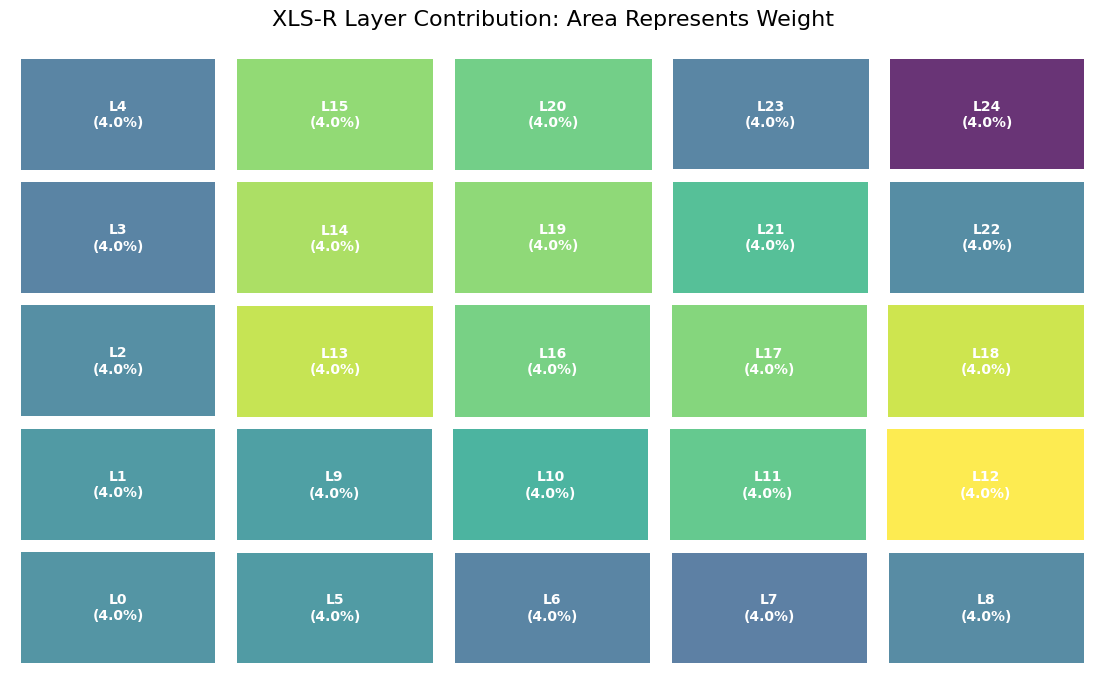

In [23]:
import matplotlib.pyplot as plt
import squarify  # pip install squarify
import torch
import numpy as np

# 1. Extract and Normalize learned weights
with torch.no_grad():
    # model.layer_weights is the parameter name from your DialectClassifier
    raw_weights = model.layer_weights.detach().cpu()
    importance_scores = torch.nn.functional.softmax(raw_weights, dim=0).numpy()

# 2. Prepare Labels and Colors
labels = [f"L{i}\n({val:.1%})" for i, val in enumerate(importance_scores)]
# Use a sequential colormap to reflect magnitude (darker/vibrant = higher)
cmap = plt.cm.viridis
norm = plt.Normalize(vmin=importance_scores.min(), vmax=importance_scores.max())
colors = [cmap(norm(value)) for value in importance_scores]

# 3. Create Treemap (Area = Weight)
plt.figure(figsize=(14, 8))
squarify.plot(
    sizes=importance_scores, 
    label=labels, 
    color=colors, 
    alpha=0.8,
    text_kwargs={'fontsize': 10, 'fontweight': 'bold', 'color': 'white'},
    pad=True # Adds spacing between blocks
)

plt.title("XLS-R Layer Contribution: Area Represents Weight", fontsize=16, pad=20)
plt.axis('off')
plt.show()

In [26]:
from tqdm.auto import tqdm
import librosa
import torch
from collections import Counter
from sklearn.metrics import classification_report

# 1. FIXED FEATURE EXTRACTION LOOP
test_data = []
print(f"Extracting features for {len(test_audio_paths)} test files...")

for path in tqdm(test_audio_paths, desc="Extraction"):
    try:
        # ROBUST LABEL MAPPING: Check for actual folder names
        # Adjust strings below to match your exact directory names
        if "bn_bd" in path.lower() or "bangladesh" in path.lower():
            label_idx = 0
        elif "bn_in" in path.lower() or "india" in path.lower():
            label_idx = 1
        else:
            # Fallback to skip files that don't match either folder
            print(f"Skipping unknown path: {path}")
            continue
        
        # Load and Extract
        audio_input, _ = librosa.load(path, sr=16000)
        features = feature_extractor(
            audio_input, 
            sampling_rate=16000, 
            return_tensors="pt"
        )
        
        test_data.append({
            "input_values": features["input_values"].squeeze(0),
            "label": torch.tensor(label_idx, dtype=torch.long)
        })
    except Exception as e:
        print(f"Error processing {path}: {e}")
        continue

# 2. VERIFICATION STEP (CRITICAL)
# This prevents the 'Support=0' error by confirming labels are loaded
final_labels = [item['label'].item() for item in test_data]
print(f"\nVerified Label Distribution: {Counter(final_labels)}")

if 0 not in final_labels or 1 not in final_labels:
    print("WARNING: One class is still missing! Check your path strings.")

# 3. INFERENCE LOOP
model.eval()
all_preds = []
all_labels = []

print(f"Generating predictions...")
with torch.no_grad():
    for item in tqdm(test_data, desc="Predicting"):
        inputs = item['input_values'].unsqueeze(0).to(device)
        label = item['label'].to(device)
        
        outputs = model(input_values=inputs)
        logits = outputs.logits
        
        prediction = torch.argmax(logits, dim=-1).item()
        
        all_preds.append(prediction)
        all_labels.append(label.item())

# 4. FINAL REPORT
print("\nFinal Test Set Report:")
print(classification_report(all_labels, all_preds, target_names=["bn_bd (Bangladesh)", "bn_in (India)"]))


Extracting features for 329 test files...


Extraction:   0%|          | 0/329 [00:00<?, ?it/s]


Verified Label Distribution: Counter({1: 165, 0: 164})
Generating predictions...


Predicting:   0%|          | 0/329 [00:00<?, ?it/s]


Final Test Set Report:
                    precision    recall  f1-score   support

bn_bd (Bangladesh)       0.73      1.00      0.84       164
     bn_in (India)       1.00      0.62      0.77       165

          accuracy                           0.81       329
         macro avg       0.86      0.81      0.80       329
      weighted avg       0.86      0.81      0.80       329



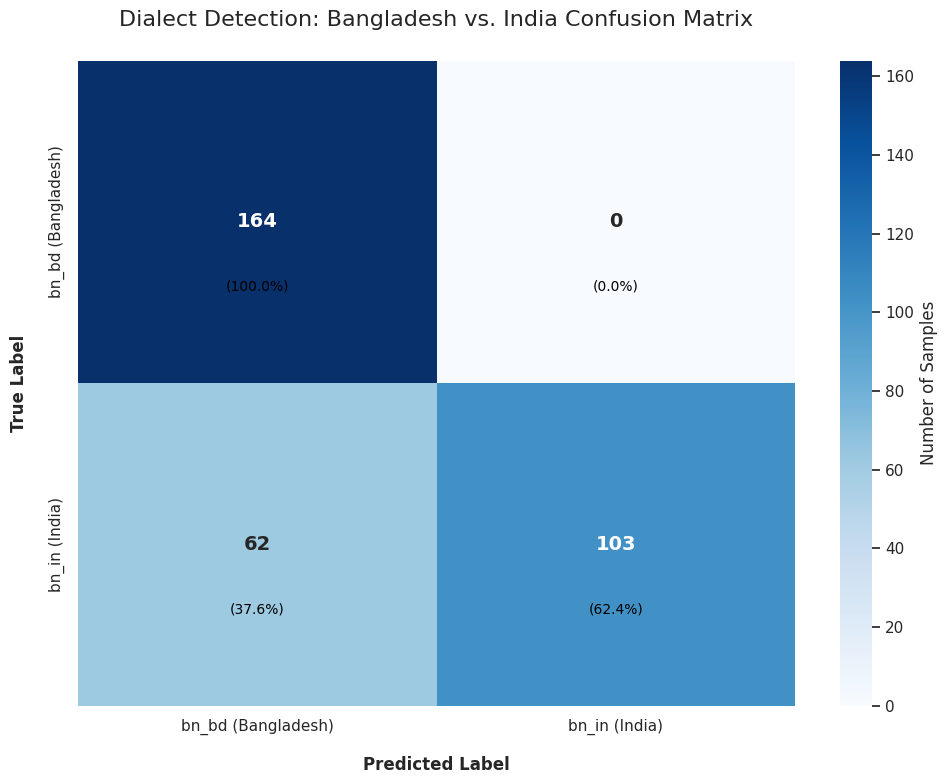

In [27]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix
import numpy as np

# 1. Define target names as used in your report
target_names = ["bn_bd (Bangladesh)", "bn_in (India)"]

# 2. Compute the Confusion Matrix
cm = confusion_matrix(all_labels, all_preds)

# 3. Setup the Visuals
plt.figure(figsize=(10, 8))
sns.set_theme(style="white") # Cleaner background for reports

# 4. Create the Heatmap
sns.heatmap(
    cm, 
    annot=True,          # Show the actual numbers in the boxes
    fmt='d',             # Format as integers
    cmap='Blues',        # Blue color gradient
    xticklabels=target_names, 
    yticklabels=target_names,
    cbar_kws={'label': 'Number of Samples'},
    annot_kws={"size": 14, "weight": "bold"} # Make numbers easy to read
)

# 5. Labels and Styling
plt.xlabel('Predicted Label', fontweight='bold', fontsize=12, labelpad=15)
plt.ylabel('True Label', fontweight='bold', fontsize=12, labelpad=15)
plt.title('Dialect Detection: Bangladesh vs. India Confusion Matrix', fontsize=16, pad=25)

# Optional: Add percentage labels to the boxes
total_samples = np.sum(cm)
for i in range(len(cm)):
    for j in range(len(cm[0])):
        percentage = cm[i, j] / np.sum(cm[i, :])
        plt.text(j+0.5, i+0.7, f'({percentage:.1%})', 
                 ha='center', va='center', color='black', fontsize=10)

plt.tight_layout()
plt.show()


/tmp/ipykernel_55/3306835776.py:7: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  inputs = torch.tensor(item['input_values']).unsqueeze(0).to(device)


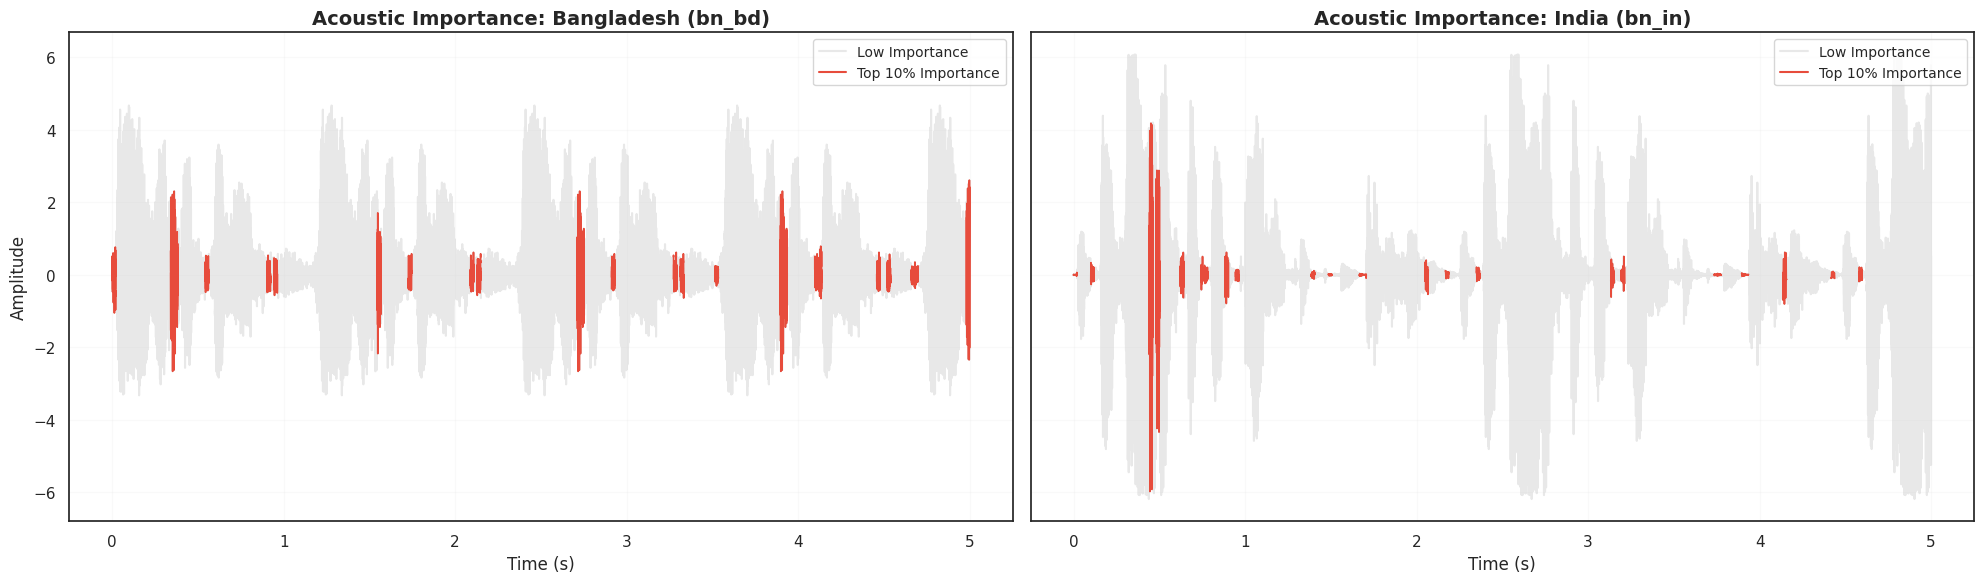

In [ ]:
import matplotlib.pyplot as plt
import torch
import numpy as np

def get_importance_data(item, model, threshold_pct=90):
    model.eval()
    inputs = torch.tensor(item['input_values']).unsqueeze(0).to(device)
    waveform = inputs.squeeze().cpu().numpy()
    
    with torch.no_grad():
        outputs = model(inputs, output_attentions=True)
        # Average across heads and sum across the 'key' dimension for the last layer
        attentions = outputs.attentions[-1][0].mean(dim=0).sum(dim=0).cpu().numpy()
    
    threshold = np.percentile(attentions, threshold_pct)
    mask = attentions >= threshold
    return waveform, mask, len(attentions)

# 1. Find one sample for each dialect
bd_sample = next(item for item in test_data if item['label'].item() == 0)
in_sample = next(item for item in test_data if item['label'].item() == 1)

# 2. Extract data for both
wav_bd, mask_bd, att_len_bd = get_importance_data(bd_sample, model)
wav_in, mask_in, att_len_in = get_importance_data(in_sample, model)

# 3. Side-by-Side Plotting with Legends
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(20, 6), sharey=True)

for ax, wav, mask, att_len, title in zip(
    [ax1, ax2], 
    [wav_bd, wav_in], 
    [mask_bd, mask_in], 
    [att_len_bd, att_len_in],
    ["Bangladesh (bn_bd)", "India (bn_in)"]
):
    ratio = len(wav) / att_len
    time_axis = np.linspace(0, len(wav) / 16000, len(wav))
    
    # Base Waveform (Labeled for Legend)
    ax.plot(time_axis, wav, color='lightgray', alpha=0.5, label='Low Importance')
    
    # Highlight High Importance Segments (Red)
    # We plot segments in a loop, but only label a "proxy" line for the legend
    for i, is_important in enumerate(mask):
        if is_important:
            start, end = int(i * ratio), int((i + 1) * ratio)
            ax.plot(time_axis[start:end], wav[start:end], color='#e74c3c', linewidth=1.2)
            
    # Add a Proxy Line for the Red Highlights Legend
    ax.plot([], [], color='#e74c3c', linewidth=1.5, label='Top 10% Importance')
            
    ax.set_title(f"Acoustic Importance: {title}", fontsize=14, fontweight='bold')
    ax.set_xlabel("Time (s)")
    ax.grid(True, alpha=0.1)
    
    # Render the legend in the upper right of each subplot
    ax.legend(loc='upper right', frameon=True, fontsize=10)

ax1.set_ylabel("Amplitude")
plt.tight_layout()
plt.show()

/tmp/ipykernel_55/898382484.py:9: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  inputs = torch.tensor(item['input_values']).unsqueeze(0).to(device)


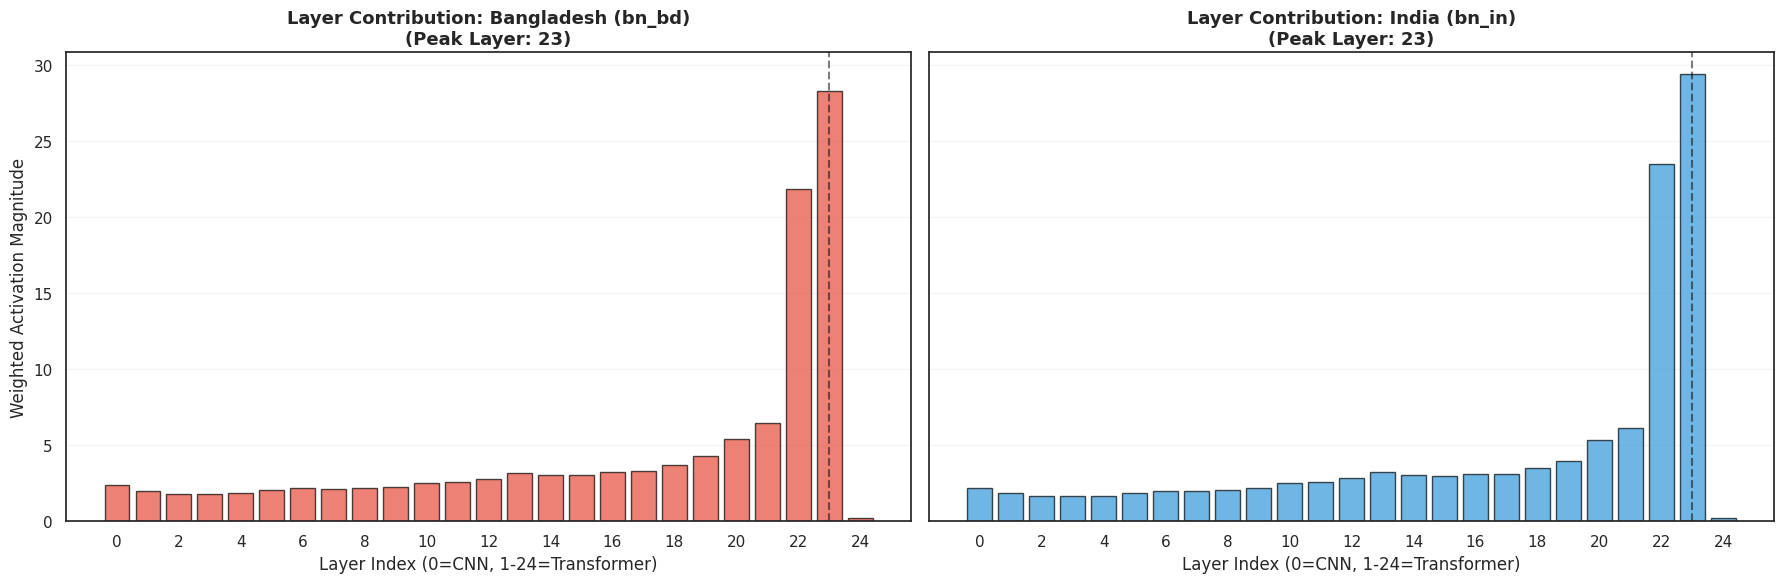

In [30]:
import torch
import numpy as np
import matplotlib.pyplot as plt
import random

def get_layer_contributions(item, model):
    model.eval()
    # 1. Extract hidden states and learned weights
    inputs = torch.tensor(item['input_values']).unsqueeze(0).to(device)
    with torch.no_grad():
        outputs = model(inputs, output_hidden_states=True)
        # hidden_states is a tuple of 25 tensors (index 0 is CNN, 1-24 are Transformers)
        hidden_states = outputs.hidden_states 
        
        # Get learned global weights (normalized via Softmax)
        weights = torch.nn.functional.softmax(model.layer_weights, dim=0).cpu().numpy()
        
    # 2. Calculate contribution: Weight * Norm(Hidden_State)
    contributions = []
    for i, h in enumerate(hidden_states):
        # We mean-pool across time [1, seq_len, hidden_dim] -> [hidden_dim]
        pooled_h = h.squeeze(0).mean(dim=0)
        norm_h = torch.norm(pooled_h, p=2).item()
        # Layer contribution = learned weight * activation magnitude
        contributions.append(weights[i] * norm_h)
        
    return np.array(contributions)

# 1. Select random samples
bd_idx = random.choice([i for i, x in enumerate(test_data) if x['label'].item() == 0])
in_idx = random.choice([i for i, x in enumerate(test_data) if x['label'].item() == 1])

# 2. Generate data
contrib_bd = get_layer_contributions(test_data[bd_idx], model)
contrib_in = get_layer_contributions(test_data[in_idx], model)

# 3. Side-by-Side Plotting
layers = np.arange(len(contrib_bd))
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 6), sharey=True)

for ax, data, title, color in zip([ax1, ax2], [contrib_bd, contrib_in], 
                                 ["Bangladesh (bn_bd)", "India (bn_in)"], ["#e74c3c", "#3498db"]):
    ax.bar(layers, data, color=color, alpha=0.7, edgecolor='black')
    peak_layer = np.argmax(data)
    ax.axvline(peak_layer, color='black', linestyle='--', alpha=0.5)
    ax.set_title(f"Layer Contribution: {title}\n(Peak Layer: {peak_layer})", fontsize=13, fontweight='bold')
    ax.set_xlabel("Layer Index (0=CNN, 1-24=Transformer)")
    ax.set_xticks(np.arange(0, 26, 2))
    ax.grid(axis='y', alpha=0.2)

ax1.set_ylabel("Weighted Activation Magnitude")
plt.tight_layout()
plt.show()


/tmp/ipykernel_55/3414959241.py:9: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  inputs = torch.tensor(item['input_values']).unsqueeze(0).to(device)


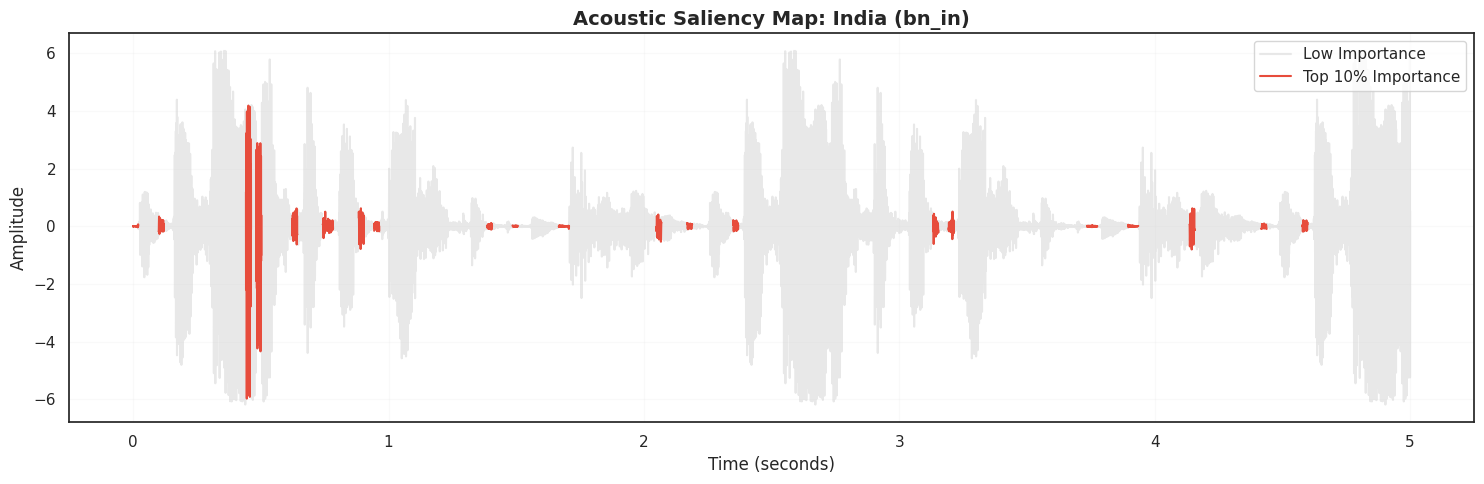

In [31]:
import matplotlib.pyplot as plt
import torch
import numpy as np

def plot_single_importance_map(item, model, threshold_pct=90):
    model.eval()
    
    # 1. Extract Waveform and Attention Data
    inputs = torch.tensor(item['input_values']).unsqueeze(0).to(device)
    waveform = inputs.squeeze().cpu().numpy()
    
    with torch.no_grad():
        outputs = model(inputs, output_attentions=True)
        # Average heads and sum keys for the final transformer layer
        attentions = outputs.attentions[-1][0].mean(dim=0).sum(dim=0).cpu().numpy()
    
    # 2. Calculate Thresholds
    threshold = np.percentile(attentions, threshold_pct)
    mask = attentions >= threshold
    
    # 3. Setup Plotting
    ratio = len(waveform) / len(attentions)
    time_axis = np.linspace(0, len(waveform) / 16000, len(waveform))
    
    plt.figure(figsize=(15, 5))
    
    # Base Waveform (Gray)
    plt.plot(time_axis, waveform, color='lightgray', alpha=0.5, label='Low Importance')
    
    # Highlight High Importance (Red)
    for i, is_important in enumerate(mask):
        if is_important:
            start, end = int(i * ratio), int((i + 1) * ratio)
            plt.plot(time_axis[start:end], waveform[start:end], color='#e74c3c', linewidth=1.5)
            
    # Proxy artist for legend
    plt.plot([], [], color='#e74c3c', linewidth=1.5, label=f'Top {100-threshold_pct}% Importance')
    
    # 4. Styling
    title_dialect = "Bangladesh (bn_bd)" if item['label'].item() == 0 else "India (bn_in)"
    plt.title(f"Acoustic Saliency Map: {title_dialect}", fontsize=14, fontweight='bold')
    plt.xlabel("Time (seconds)")
    plt.ylabel("Amplitude")
    plt.legend(loc='upper right')
    plt.grid(True, alpha=0.1)
    plt.tight_layout()
    plt.show()

# EXECUTION: Pass a single sample (e.g., the first sample in test_data)
plot_single_importance_map(test_data[0], model)
